# CRISP Predictive Modeling Pipeline - End-to-End Demonstration

**Complete walkthrough of the predictive modeling pipeline from data to deployment**

##  **IMPORTANT PREREQUISITES**

**Before running this notebook, you MUST:**
1. **Complete the CRISP pipeline data extraction** by running all pipeline modules (1-5)
2. **Ensure patient data exists** in `../extracted_patient_data/` directory
3. **Have at least one patient** with ICU admission and labels

**To prepare the data:**
```bash
# From the project root directory, run:
python pipeline_modules/run_all_module.py
```

This will extract patient data from OMOP CDM tables and generate the required `extracted_patient_data/` directory.

---

## **What This Notebook Does**
1. **Feature Extraction** - Extract time series and static features from OMOP data
2. **Traditional Model Training** - Train LogisticRegression, RandomForest, GradientBoosting, XGBoost
3. **Deep Learning Training** - Train MLP, LSTM, and TCN models
4. **Model Evaluation** - Generate performance metrics and visualizations
5. **Results Analysis** - Compare models and provide recommendations

## **Clinical Prediction Tasks**
- **Mortality**: 7-day, 30-day ICU mortality
- **Readmission**: 7-day, 30-day, 90-day readmission
- **Length of Stay**: >3 days, >7 days
- **Sepsis**: 24h, 48h, during ICU sepsis

In [1]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
import time
from datetime import datetime
import os

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("CRISP Predictive Modeling Pipeline - Interactive Demo")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)
print("\nThis notebook will execute the complete pipeline step by step")
print("   You can follow along and see the results in real-time!")

CRISP Predictive Modeling Pipeline - Interactive Demo
Started: 2025-09-02 20:03:43

This notebook will execute the complete pipeline step by step
   You can follow along and see the results in real-time!


## Step 1: Data Preparation Check

First, let's verify that we have the required patient data for feature extraction.

In [2]:
def check_data_availability():
    """Check if patient data is available for feature extraction"""
    print("**CHECKING DATA AVAILABILITY**\n")
    
    # Check for patient data
    data_dir = Path('../extracted_patient_data')
    if data_dir.exists():
        patient_files = list(data_dir.rglob('patient_labels.json'))
        print(f"[SUCCESS] Found patient data directory: {data_dir}")
        print(f"Number of patients with labels: {len(patient_files)}")
        
        if patient_files:
            # Sample one patient to show structure
            sample_file = patient_files[0]
            with open(sample_file, 'r') as f:
                sample_data = json.load(f)
            
            print(f"\n**Sample Patient Data Structure:**")
            print(f"   Patient ID: {sample_data.get('patient_id', 'N/A')}")
            print(f"   ICU Admission: {sample_data.get('has_icu_admission', 'N/A')}")
            
            # Show available prediction targets
            targets = []
            if 'mortality' in sample_data:
                targets.extend([f"Mortality: {list(sample_data['mortality'].keys())}"]) 
            if 'readmission' in sample_data:
                targets.extend([f"Readmission: {list(sample_data['readmission'].keys())}"])
            if 'los' in sample_data:
                targets.extend([f"Length of Stay: {list(sample_data['los'].keys())}"])
            if any(k.startswith('sepsis') or k.startswith('has_sepsis') for k in sample_data.keys()):
                sepsis_keys = [k for k in sample_data.keys() if 'sepsis' in k]
                targets.extend([f"Sepsis: {sepsis_keys}"])
            
            print(f"\n**Available Prediction Targets:**")
            for target in targets:
                print(f"   - {target}")
            
            return True, len(patient_files)
        else:
            print("[FAILED] No patient label files found")
            return False, 0
    else:
        print(f"[FAILED] Patient data directory not found: {data_dir}")
        print("\n**To generate patient data:**")
        print("   1. Run the CRISP pipeline modules 1-5 first")
        print("   2. Ensure extracted_patient_data/ directory exists")
        return False, 0

# Check data availability
data_available, num_patients = check_data_availability()

if data_available:
    print(f"\n**Ready to proceed!** Found data for {num_patients} patients")
else:
    print(f"\n**Cannot proceed without patient data**")
    print("   Please run the CRISP data extraction pipeline first")

**CHECKING DATA AVAILABILITY**

[SUCCESS] Found patient data directory: ../extracted_patient_data
Number of patients with labels: 538

**Sample Patient Data Structure:**
   Patient ID: 400000004370567
   ICU Admission: 0

**Available Prediction Targets:**
   - Mortality: ['mortality_icu_48h', 'mortality_icu_7day', 'mortality_icu_30day', 'days_to_death', 'death_after_discharge', 'death_datetime']
   - Readmission: ['has_readmission', 'days_to_first_readmission', 'readmission_within_7days', 'readmission_within_30days', 'readmission_within_90days']
   - Length of Stay: ['los_greater_than_3days', 'los_greater_than_7days', 'last_icu_los_days']
   - Sepsis: ['sepsis']

**Ready to proceed!** Found data for 538 patients


## Step 2: Feature Extraction

Extract time series features (for mortality/readmission/LOS) and static features (for sepsis prediction).

In [3]:
def run_feature_extraction():
    """Execute feature extraction step"""
    print("**STEP 1: FEATURE EXTRACTION**\n")
    print("Extracting features from patient data...")
    print("- Time series features: 4-hour windows, 24-hour observation")
    print("- Static features: Demographics + pre-ICU conditions")
    
    start_time = time.time()
    
    # Run feature extraction
    result = subprocess.run([
        'python', 'predictive_modeling/1_feature_engineering/run_feature_extraction.py',
        '--time-window', '4',
        '--min-observation', '24',
        '--output-dir', 'predictive_modeling/modeling_results/features'
    ], 
    cwd='../', 
    capture_output=True, 
    text=True)
    
    duration = time.time() - start_time
    
    if result.returncode == 0:
        print(f"\n[SUCCESS] Feature extraction completed in {duration:.1f}s")
        
        # Parse output for key statistics
        lines = result.stdout.split('\n')
        for line in lines:
            if 'Samples:' in line or 'Features:' in line or 'Data completeness:' in line:
                print(f"   {line.strip()}")
        
        # Check generated files
        features_dir = Path('../predictive_modeling/modeling_results/features')
        if features_dir.exists():
            feature_files = list(features_dir.glob('*.csv'))
            print(f"\nGenerated {len(feature_files)} feature files:")
            for f in feature_files:
                print(f"   {f.name}")
        
        return True
    else:
        print(f"\n[FAILED] Feature extraction failed after {duration:.1f}s")
        print(f"Error: {result.stderr}")
        return False

# Run feature extraction if data is available
if data_available:
    feature_success = run_feature_extraction()
else:
    print("[SKIP] Skipping feature extraction - no patient data available")
    feature_success = False

**STEP 1: FEATURE EXTRACTION**

Extracting features from patient data...
- Time series features: 4-hour windows, 24-hour observation
- Static features: Demographics + pre-ICU conditions

[SUCCESS] Feature extraction completed in 40.7s
   Samples: 255
   Features: 2974
   Data completeness: 9.06%
   Samples: 413
   Features: 107
   Data completeness: 13.75%

Generated 2 feature files:
   sepsis_static_features.csv
   time_series_features_4h_window.csv


## Step 3: Traditional Model Training

Train traditional machine learning models (LogisticRegression, RandomForest, GradientBoosting, XGBoost).

In [4]:
def run_traditional_training():
    """Execute traditional model training"""
    print("**STEP 2: TRADITIONAL MODEL TRAINING**\n")
    print("Training models: LogisticRegression, RandomForest, GradientBoosting, XGBoost")
    print("Tasks: Mortality, Readmission, Length of Stay, Sepsis")
    
    start_time = time.time()
    
    # Run traditional model training
    result = subprocess.run([
        'python', 'predictive_modeling/2_model_training/run_traditional_models.py',
        '--input-dir', 'predictive_modeling/modeling_results/features',
        '--output-dir', 'predictive_modeling/modeling_results/models/traditional',
        '--time-window', '4',
        '--tasks', 'mortality,readmission,los,sepsis',
        '--models', 'LogisticRegression,RandomForest,GradientBoosting,XGBoost'
    ], 
    cwd='../', 
    capture_output=True, 
    text=True)
    
    duration = time.time() - start_time
    
    if result.returncode == 0:
        print(f"\n[SUCCESS] Traditional model training completed in {duration:.1f}s")
        
        # Parse output for performance summary
        lines = result.stdout.split('\n')
        in_summary = False
        for line in lines:
            if 'TRAINING SUMMARY' in line:
                in_summary = True
            elif in_summary and ('MORTALITY:' in line or 'READMISSION:' in line or 'LOS:' in line or 'SEPSIS:' in line):
                print(f"   {line.strip()}")
            elif in_summary and ('Targets trained:' in line or 'Average AUROC:' in line or 'Best:' in line):
                print(f"      {line.strip()}")
        
        # Check generated models
        models_dir = Path('../predictive_modeling/modeling_results/models/traditional')
        if models_dir.exists():
            model_files = list(models_dir.rglob('*.pkl'))
            print(f"\nTrained {len(model_files)} traditional models")
        
        return True
    else:
        print(f"\n[FAILED] Traditional model training failed after {duration:.1f}s")
        print(f"Error: {result.stderr}")
        return False

# Run traditional model training if features are available
if 'feature_success' in locals() and feature_success:
    traditional_success = run_traditional_training()
else:
    print("[SKIP] Skipping traditional model training - features not available")
    traditional_success = False

**STEP 2: TRADITIONAL MODEL TRAINING**

Training models: LogisticRegression, RandomForest, GradientBoosting, XGBoost
Tasks: Mortality, Readmission, Length of Stay, Sepsis

[SUCCESS] Traditional model training completed in 42.3s
   MORTALITY:
      Targets trained: 2
      Average AUROC: 0.643
      Best: mortality_30day (AUROC=0.717)
   READMISSION:
      Targets trained: 3
      Average AUROC: 0.793
      Best: readmission_7days (AUROC=0.941)
   LOS:
      Targets trained: 2
      Average AUROC: 0.614
      Best: los_greater_3days (AUROC=0.614)
   SEPSIS:
      Targets trained: 3
      Average AUROC: 0.739
      Best: sepsis_within_7days (AUROC=0.779)

Trained 80 traditional models


## Step 4: Deep Learning Model Training

Train deep learning models including:
- **MLP** (Multi-Layer Perceptron): Fully connected neural network for tabular features
- **LSTM** (Long Short-Term Memory): Sequential model for temporal patterns
- **TCN** (Temporal Convolutional Network): Convolutional model for time series

Note: You can choose which models to train by modifying the `model_types` parameter below.

In [5]:
def run_deep_learning_training(model_types=['MLP']):
    """Execute deep learning model training
    
    Args:
        model_types: List of model types to train. Options: 'MLP', 'LSTM', 'TCN'
    """
    print("**STEP 3: DEEP LEARNING MODEL TRAINING**\n")
    print(f"Training models: {', '.join(model_types)}")
    
    all_results = {}
    overall_success = False
    
    for model_type in model_types:
        print(f"\n--- Training {model_type} Model ---")
        
        if model_type == 'MLP':
            print("Architecture: Input -> Dense(256) -> Dense(128) -> Dense(64) -> Output")
        elif model_type == 'LSTM':
            print("Architecture: Static+Temporal -> LSTM(128) -> Dense(64) -> Output")
            print("Note: Uses sequential data with temporal features")
        elif model_type == 'TCN':
            print("Architecture: Static+Temporal -> TCN(channels=[64,128,256]) -> Output")
            print("Note: Uses causal convolutions for temporal patterns")
        
        start_time = time.time()
        
        # Run deep learning model training
        result = subprocess.run([
            'python', 'predictive_modeling/2_model_training/run_DL_models.py',
            '--input-dir', 'predictive_modeling/modeling_results/features',
            '--output-dir', 'predictive_modeling/modeling_results/models/deep_learning',
            '--time-window', '4',
            '--model-type', model_type,
            '--tasks', 'mortality,readmission,los,sepsis',
            '--epochs', '100',
            '--batch-size', '32'
        ], 
        cwd='../', 
        capture_output=True, 
        text=True)
        
        duration = time.time() - start_time
        
        if result.returncode == 0:
            print(f"[SUCCESS] {model_type} training completed in {duration:.1f}s")
            overall_success = True
            
            # Parse output for performance summary
            lines = result.stdout.split('\n')
            in_summary = False
            model_metrics = {}
            
            for line in lines:
                if 'TRAINING SUMMARY' in line:
                    in_summary = True
                elif in_summary and ('MORTALITY:' in line or 'READMISSION:' in line or 
                                    'LOS:' in line or 'SEPSIS:' in line):
                    print(f"   {line.strip()}")
                elif in_summary and ('Average AUROC:' in line or 'Average AUPRC:' in line):
                    # Extract metrics
                    if 'AUROC' in line:
                        try:
                            auroc = float(line.split(':')[-1].strip())
                            model_metrics['auroc'] = auroc
                        except:
                            pass
                    if 'AUPRC' in line:
                        try:
                            auprc = float(line.split(':')[-1].strip())
                            model_metrics['auprc'] = auprc
                        except:
                            pass
                    print(f"      {line.strip()}")
            
            all_results[model_type] = {
                'success': True,
                'duration': duration,
                'metrics': model_metrics
            }
            
        else:
            print(f"[FAILED] {model_type} training failed after {duration:.1f}s")
            print(f"Error: {result.stderr[:500]}")  # Show first 500 chars of error
            all_results[model_type] = {
                'success': False,
                'duration': duration,
                'error': result.stderr
            }
    
    # Summary
    print(f"\n**Deep Learning Training Summary**")
    successful_models = [m for m, r in all_results.items() if r['success']]
    print(f"Successfully trained: {', '.join(successful_models) if successful_models else 'None'}")
    
    # Check generated models
    models_dir = Path('../predictive_modeling/modeling_results/models/deep_learning')
    if models_dir.exists():
        for model_type in successful_models:
            model_dir = models_dir / model_type.lower()
            if model_dir.exists():
                model_files = list(model_dir.glob('*.pt'))
                print(f"   {model_type}: {len(model_files)} model files")
    
    return overall_success, all_results

# Choose which models to train
# Options: 'MLP', 'LSTM', 'TCN' or any combination
MODEL_TYPES_TO_TRAIN = ['MLP', 'LSTM', 'TCN']  # Train all three types

# Run deep learning training if features are available
if 'feature_success' in locals() and feature_success:
    dl_success, dl_results = run_deep_learning_training(MODEL_TYPES_TO_TRAIN)
else:
    print("[SKIP] Skipping deep learning training - features not available")
    dl_success = False
    dl_results = {}

**STEP 3: DEEP LEARNING MODEL TRAINING**

Training models: MLP, LSTM, TCN

--- Training MLP Model ---
Architecture: Input -> Dense(256) -> Dense(128) -> Dense(64) -> Output
[SUCCESS] MLP training completed in 14.8s
   MORTALITY:
      Average AUROC: 0.755
      Average AUPRC: 0.284
   READMISSION:
      Average AUROC: 0.730
      Average AUPRC: 0.399
   LOS:
      Average AUROC: 0.554
      Average AUPRC: 0.448
   SEPSIS:
      Average AUROC: 0.703
      Average AUPRC: 0.206

--- Training LSTM Model ---
Architecture: Static+Temporal -> LSTM(128) -> Dense(64) -> Output
Note: Uses sequential data with temporal features
[SUCCESS] LSTM training completed in 47.0s
   MORTALITY:
      Average AUROC: 0.659
      Average AUPRC: 0.179
   READMISSION:
      Average AUROC: 0.648
      Average AUPRC: 0.416
   LOS:
      Average AUROC: 0.505
      Average AUPRC: 0.446
   SEPSIS:
      Average AUROC: 0.737
      Average AUPRC: 0.228

--- Training TCN Model ---
Architecture: Static+Temporal -> TCN(ch

## Step 5: Model Evaluation

Evaluate all trained models and generate comprehensive performance reports.

In [6]:
def run_model_evaluation():
    """Execute model evaluation"""
    print("**STEP 4: MODEL EVALUATION**\n")
    print("Evaluating all trained models...")
    print("Generating: AUROC/AUPRC metrics, ROC curves, PR curves, reports")
    
    start_time = time.time()
    
    # Run model evaluation
    result = subprocess.run([
        'python', 'predictive_modeling/3_evaluation/run_evaluation.py',
        '--model-dir', 'predictive_modeling/modeling_results/models',
        '--feature-dir', 'predictive_modeling/modeling_results/features',
        '--output-dir', 'predictive_modeling/modeling_results/evaluation',
        '--time-window', '4'
    ], 
    cwd='../', 
    capture_output=True, 
    text=True)
    
    duration = time.time() - start_time
    
    if result.returncode == 0:
        print(f"\n[SUCCESS] Model evaluation completed in {duration:.1f}s")
        
        # Check generated files
        eval_dir = Path('../predictive_modeling/modeling_results/evaluation')
        if eval_dir.exists():
            plot_files = list(eval_dir.rglob('*.png'))
            json_files = list(eval_dir.rglob('*.json'))
            report_files = list(eval_dir.rglob('*.md'))
            
            print(f"\nGenerated evaluation outputs:")
            print(f"   Plots: {len(plot_files)}")
            print(f"   Reports: {len(report_files)}")
            print(f"   Metrics: {len(json_files)}")
        
        return True
    else:
        print(f"\n[FAILED] Model evaluation failed after {duration:.1f}s")
        print(f"Error: {result.stderr}")
        return False

# Run evaluation if models are available
if ('traditional_success' in locals() and traditional_success) or ('dl_success' in locals() and dl_success):
    eval_success = run_model_evaluation()
else:
    print("[SKIP] Skipping model evaluation - no trained models available")
    eval_success = False

**STEP 4: MODEL EVALUATION**

Evaluating all trained models...
Generating: AUROC/AUPRC metrics, ROC curves, PR curves, reports

[SUCCESS] Model evaluation completed in 30.9s

Generated evaluation outputs:
   Plots: 128
   Reports: 1
   Metrics: 1


## Step 6: Results Analysis and Comparison

Load and analyze all results to provide model performance comparison and recommendations.

In [7]:
def load_and_analyze_results():
    """Load all results and create comprehensive analysis"""
    print("**STEP 5: RESULTS ANALYSIS**\n")
    
    results_data = []
    models_found = 0
    
    # Load traditional model results
    trad_dir = Path('../predictive_modeling/modeling_results/models/traditional')
    if trad_dir.exists():
        for model_dir in trad_dir.iterdir():
            if model_dir.is_dir():
                # Keep original model name for category
                model_name_raw = model_dir.name
                model_name = model_dir.name.replace('_', ' ').title()
                for metrics_file in model_dir.glob('*_metrics.json'):
                    parts = metrics_file.stem.replace('_metrics', '').split('_')
                    if len(parts) >= 2:
                        task = parts[0]
                        target = '_'.join(parts[1:])
                        
                        with open(metrics_file, 'r') as f:
                            metrics = json.load(f)
                        
                        # Use specific model name as category
                        model_category = model_name
                        
                        results_data.append({
                            'Model_Type': 'Traditional',
                            'Model_Name': model_name,
                            'Model_Category': model_category,
                            'Task': task.title(),
                            'Target': target.replace('_', ' ').title(),
                            'AUROC': metrics.get('auroc', 0),
                            'AUPRC': metrics.get('auprc', 0)
                        })
                        models_found += 1
    
    # Load deep learning results (now supports multiple model types)
    dl_dir = Path('../predictive_modeling/modeling_results/models/deep_learning')
    if dl_dir.exists():
        for model_dir in dl_dir.iterdir():
            if model_dir.is_dir():
                # Keep the original case for DL models to distinguish them
                model_name = model_dir.name.upper()
                for metrics_file in model_dir.glob('*_metrics.json'):
                    parts = metrics_file.stem.replace('_metrics', '').split('_')
                    if len(parts) >= 2:
                        task = parts[0]
                        target = '_'.join(parts[1:])
                        
                        with open(metrics_file, 'r') as f:
                            metrics = json.load(f)
                        
                        # Use specific category for different DL models
                        dl_category = f'Deep Learning ({model_name})'
                        
                        results_data.append({
                            'Model_Type': 'Deep Learning',
                            'Model_Name': model_name,
                            'Model_Category': dl_category,
                            'Task': task.title(),
                            'Target': target.replace('_', ' ').title(),
                            'AUROC': metrics.get('auroc', 0),
                            'AUPRC': metrics.get('auprc', 0)
                        })
                        models_found += 1
    
    if results_data:
        df = pd.DataFrame(results_data)
        
        # Model_Category should already be set for all models
        if 'Model_Category' not in df.columns:
            df['Model_Category'] = df['Model_Name']
        
        df['Combined_Score'] = 0.6 * df['AUROC'] + 0.4 * df['AUPRC']
        
        print(f"**PERFORMANCE SUMMARY**")
        print(f"   Total model evaluations: {len(df)}")
        print(f"   Model types: {', '.join(df['Model_Type'].unique())}")
        
        # Show unique model names
        unique_models = df['Model_Name'].unique()
        print(f"   Models trained: {', '.join(unique_models)}")
        
        print(f"   Tasks: {', '.join(df['Task'].unique())}")
        print(f"   Best AUROC: {df['AUROC'].max():.3f}")
        print(f"   Best AUPRC: {df['AUPRC'].max():.3f}")
        
        # Best model per category
        print(f"\n**Best Models by Category:**")
        for category in df['Model_Category'].unique():
            cat_df = df[df['Model_Category'] == category]
            best_idx = cat_df['Combined_Score'].idxmax()
            best_row = cat_df.loc[best_idx]
            print(f"   {category}: AUROC={best_row['AUROC']:.3f}, AUPRC={best_row['AUPRC']:.3f}")
        
        return df
    else:
        print("[FAILED] No model results found to analyze")
        return None

# Load and analyze results if evaluation succeeded
if 'eval_success' in locals() and eval_success:
    results_df = load_and_analyze_results()
else:
    print("[SKIP] Skipping results analysis - no evaluation results available")
    results_df = None

**STEP 5: RESULTS ANALYSIS**

**PERFORMANCE SUMMARY**
   Total model evaluations: 70
   Model types: Traditional, Deep Learning
   Models trained: Xgboost, Randomforest, Gradientboosting, Logisticregression, TCN, MLP, LSTM
   Tasks: Los, Readmission, Mortality, Sepsis
   Best AUROC: 0.941
   Best AUPRC: 0.681

**Best Models by Category:**
   Xgboost: AUROC=0.819, AUPRC=0.462
   Randomforest: AUROC=0.899, AUPRC=0.507
   Gradientboosting: AUROC=0.747, AUPRC=0.546
   Logisticregression: AUROC=0.941, AUPRC=0.681
   Deep Learning (TCN): AUROC=0.763, AUPRC=0.574
   Deep Learning (MLP): AUROC=0.718, AUPRC=0.558
   Deep Learning (LSTM): AUROC=0.793, AUPRC=0.582


## Step 7: Performance Visualization

Create visualizations to compare model performance across tasks.

**PERFORMANCE VISUALIZATION**



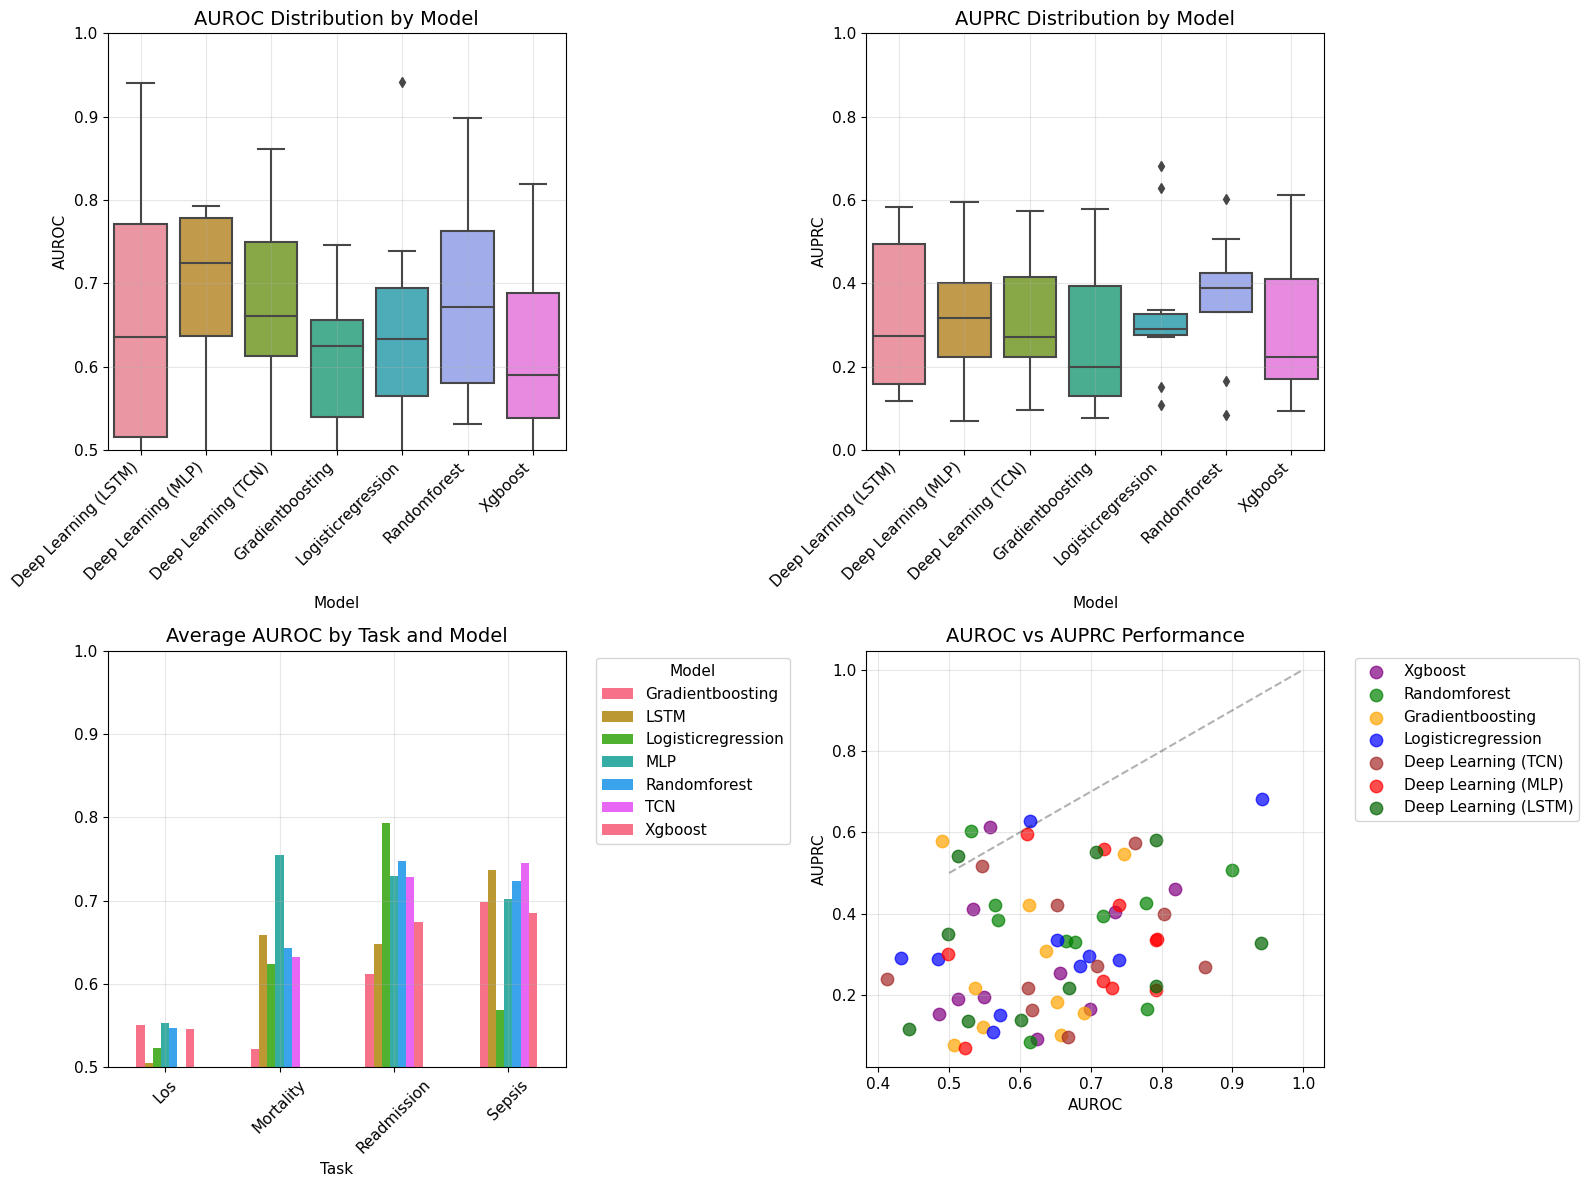


**TOP PERFORMING MODELS**



,Model_Name,Model_Category,Task,Target,AUROC,AUPRC,Combined_Score
35,Logisticregression,Logisticregression,Readmission,Readmission 7Days,0.941489,0.681090,0.837330
15,Randomforest,Randomforest,Readmission,Readmission 7Days,0.898936,0.507143,0.742219
65,LSTM,Deep Learning (LSTM),Readmission,Readmission 7Days,0.792553,0.582258,0.708435
68,LSTM,Deep Learning (LSTM),Sepsis,Sepsis Within 48H,0.939873,0.327679,0.694995
42,TCN,Deep Learning (TCN),Readmission,Readmission 90Days,0.762987,0.573696,0.687271
5,Xgboost,Xgboost,Readmission,Readmission 7Days,0.819149,0.461566,0.676116
26,Gradientboosting,Gradientboosting,Sepsis,Has Sepsis After Icu,0.746575,0.545634,0.666199
55,MLP,Deep Learning (MLP),Readmission,Readmission 7Days,0.718085,0.558036,0.654065
62,LSTM,Deep Learning (LSTM),Readmission,Readmission 90Days,0.707792,0.550726,0.644966
45,TCN,Deep Learning (TCN),Readmission,Readmission 7Days,0.803191,0.397917,0.641082



**BEST MODEL PER ARCHITECTURE**

Deep Learning (LSTM)           | Task: Readmission  | Target: Readmission 7Days         | AUROC: 0.793 | AUPRC: 0.582
Deep Learning (MLP)            | Task: Readmission  | Target: Readmission 7Days         | AUROC: 0.718 | AUPRC: 0.558
Deep Learning (TCN)            | Task: Readmission  | Target: Readmission 90Days        | AUROC: 0.763 | AUPRC: 0.574
Gradientboosting               | Task: Sepsis       | Target: Has Sepsis After Icu      | AUROC: 0.747 | AUPRC: 0.546
Logisticregression             | Task: Readmission  | Target: Readmission 7Days         | AUROC: 0.941 | AUPRC: 0.681
Randomforest                   | Task: Readmission  | Target: Readmission 7Days         | AUROC: 0.899 | AUPRC: 0.507
Xgboost                        | Task: Readmission  | Target: Readmission 7Days         | AUROC: 0.819 | AUPRC: 0.462


In [8]:
if results_df is not None and len(results_df) > 0:
    print("**PERFORMANCE VISUALIZATION**\n")
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. AUROC comparison by model category (shows different models separately)
    if 'Model_Category' in results_df.columns:
        category_order = sorted(results_df['Model_Category'].unique())
        sns.boxplot(data=results_df, x='Model_Category', y='AUROC', order=category_order, ax=axes[0,0])
        axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')
    else:
        sns.boxplot(data=results_df, x='Model_Type', y='AUROC', ax=axes[0,0])
    axes[0,0].set_title('AUROC Distribution by Model', fontsize=14)
    axes[0,0].set_xlabel('Model')
    axes[0,0].set_ylim(0.5, 1.0)
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. AUPRC comparison by model category
    if 'Model_Category' in results_df.columns:
        sns.boxplot(data=results_df, x='Model_Category', y='AUPRC', order=category_order, ax=axes[0,1])
        axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')
    else:
        sns.boxplot(data=results_df, x='Model_Type', y='AUPRC', ax=axes[0,1])
    axes[0,1].set_title('AUPRC Distribution by Model', fontsize=14)
    axes[0,1].set_xlabel('Model')
    axes[0,1].set_ylim(0, 1.0)
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Performance by task (showing each model name)
    task_performance = results_df.groupby(['Task', 'Model_Name'])['AUROC'].mean().reset_index()
    
    # Create pivot table for better visualization
    pivot_task = task_performance.pivot(index='Task', columns='Model_Name', values='AUROC')
    pivot_task.plot(kind='bar', ax=axes[1,0], rot=45)
    axes[1,0].set_title('Average AUROC by Task and Model', fontsize=14)
    axes[1,0].set_ylim(0.5, 1.0)
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 4. AUROC vs AUPRC scatter with model names
    # Use different colors for different model categories
    color_map = {
        'Logisticregression': 'blue',
        'Randomforest': 'green',
        'Gradientboosting': 'orange',
        'Xgboost': 'purple',
        'Deep Learning (MLP)': 'red',
        'Deep Learning (LSTM)': 'darkgreen',
        'Deep Learning (TCN)': 'brown'
    }
    
    if 'Model_Category' in results_df.columns:
        for category in results_df['Model_Category'].unique():
            data = results_df[results_df['Model_Category'] == category]
            # Use color from map or default to gray
            color = color_map.get(category, 'gray')
            axes[1,1].scatter(data['AUROC'], data['AUPRC'], 
                            c=color, 
                            label=category, alpha=0.7, s=80)
    else:
        for model_type in results_df['Model_Type'].unique():
            data = results_df[results_df['Model_Type'] == model_type]
            axes[1,1].scatter(data['AUROC'], data['AUPRC'], 
                            c='blue' if model_type == 'Traditional' else 'red', 
                            label=model_type, alpha=0.7, s=80)
    
    axes[1,1].set_xlabel('AUROC')
    axes[1,1].set_ylabel('AUPRC')
    axes[1,1].set_title('AUROC vs AUPRC Performance', fontsize=14)
    axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1,1].grid(True, alpha=0.3)
    
    # Add diagonal reference line
    axes[1,1].plot([0.5, 1], [0.5, 1], 'k--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Display top performing models
    print("\n**TOP PERFORMING MODELS**\n")
    if 'Model_Category' in results_df.columns:
        top_models = results_df.nlargest(10, 'Combined_Score')[
            ['Model_Name', 'Model_Category', 'Task', 'Target', 'AUROC', 'AUPRC', 'Combined_Score']
        ]
    else:
        top_models = results_df.nlargest(10, 'Combined_Score')[
            ['Model_Name', 'Model_Type', 'Task', 'Target', 'AUROC', 'AUPRC', 'Combined_Score']
        ]
    display(top_models)
    
    # Best model comparison by architecture
    if 'Model_Category' in results_df.columns:
        print("\n**BEST MODEL PER ARCHITECTURE**\n")
        for category in sorted(results_df['Model_Category'].unique()):
            cat_df = results_df[results_df['Model_Category'] == category]
            best_idx = cat_df['Combined_Score'].idxmax()
            best = cat_df.loc[best_idx]
            print(f"{category:30s} | Task: {best['Task']:12s} | Target: {best['Target']:25s} | AUROC: {best['AUROC']:.3f} | AUPRC: {best['AUPRC']:.3f}")
    
else:
    print("No results available for visualization")

## Step 8: Pipeline Summary

Comprehensive summary of the entire pipeline execution.

In [9]:
def display_pipeline_summary():
    """Display comprehensive pipeline summary"""
    print("**PIPELINE EXECUTION SUMMARY**\n")
    
    # Check pipeline completion status by examining actual files/directories
    steps_completed = []
    
    # Check for patient data
    data_dir = Path('../extracted_patient_data')
    data_available = data_dir.exists() and list(data_dir.rglob('patient_labels.json'))
    
    if data_available:
        steps_completed.append("[SUCCESS] Data Check: Patient data found")
    else:
        steps_completed.append("[FAILED] Data Check: No patient data")
    
    # Check for feature files
    features_dir = Path('../predictive_modeling/modeling_results/features')
    feature_files = list(features_dir.glob('*.csv')) if features_dir.exists() else []
    feature_success = len(feature_files) > 0
    
    if feature_success:
        steps_completed.append("[SUCCESS] Feature Extraction: Completed successfully")
    else:
        steps_completed.append("[FAILED] Feature Extraction: Failed or skipped")
    
    # Check for traditional model files
    trad_models_dir = Path('../predictive_modeling/modeling_results/models/traditional')
    trad_model_files = list(trad_models_dir.rglob('*.pkl')) if trad_models_dir.exists() else []
    traditional_success = len(trad_model_files) > 0
    
    if traditional_success:
        steps_completed.append("[SUCCESS] Traditional Models: Trained successfully")
    else:
        steps_completed.append("[FAILED] Traditional Models: Failed or skipped")
    
    # Check for deep learning model files
    dl_models_dir = Path('../predictive_modeling/modeling_results/models/deep_learning')
    dl_model_files = list(dl_models_dir.rglob('*.pt')) if dl_models_dir.exists() else []
    dl_success = len(dl_model_files) > 0
    
    if dl_success:
        steps_completed.append("[SUCCESS] Deep Learning: Trained successfully")
    else:
        steps_completed.append("[FAILED] Deep Learning: Failed or skipped")
    
    # Check for evaluation files
    eval_dir = Path('../predictive_modeling/modeling_results/evaluation')
    eval_files = list(eval_dir.rglob('*.json')) if eval_dir.exists() else []
    eval_success = len(eval_files) > 0
    
    if eval_success:
        steps_completed.append("[SUCCESS] Evaluation: Completed successfully")
    else:
        steps_completed.append("[FAILED] Evaluation: Failed or skipped")
    
    print("**Pipeline Steps:**")
    for step in steps_completed:
        print(f"   {step}")
    
    # Check generated files
    results_dir = Path('../predictive_modeling/modeling_results')
    if results_dir.exists():
        feature_file_count = len(feature_files)
        model_file_count = len(trad_model_files) + len(dl_model_files)
        plot_files = list(results_dir.rglob('*.png'))
        plot_file_count = len(plot_files)
        
        print(f"\n**Generated Files:**")
        print(f"   Feature files: {feature_file_count}")
        print(f"   Model files: {model_file_count}")
        print(f"   Plot files: {plot_file_count}")
        print(f"\nAll results saved in: ../predictive_modeling/modeling_results/")
    else:
        print(f"\n**Generated Files:** No results directory found")
    
    # Final status
    successful_steps = sum(1 for step in steps_completed if '[SUCCESS]' in step)
    total_steps = len(steps_completed)
    
    print(f"\n**Final Status**: {successful_steps}/{total_steps} steps completed")
    
    if successful_steps == total_steps:
        print("**SUCCESS**: Complete pipeline executed successfully!")
        print("   Ready for model deployment and clinical validation")
    elif successful_steps > 0:
        print("**PARTIAL**: Some steps completed successfully")
        print("   Pipeline has generated results - check individual step outputs above")
    else:
        print("**FAILED**: No pipeline steps completed successfully")
        print("   Review error messages above and ensure data availability")

# Display final summary
display_pipeline_summary()

print(f"\n\n**Pipeline Demo Completed**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("**CRISP Predictive Modeling Pipeline - End-to-End Demonstration**")

**PIPELINE EXECUTION SUMMARY**

**Pipeline Steps:**
   [SUCCESS] Data Check: Patient data found
   [SUCCESS] Feature Extraction: Completed successfully
   [SUCCESS] Traditional Models: Trained successfully
   [SUCCESS] Deep Learning: Trained successfully
   [SUCCESS] Evaluation: Completed successfully

**Generated Files:**
   Feature files: 2
   Model files: 110
   Plot files: 128

All results saved in: ../predictive_modeling/modeling_results/

**Final Status**: 5/5 steps completed
**SUCCESS**: Complete pipeline executed successfully!
   Ready for model deployment and clinical validation


**Pipeline Demo Completed**: 2025-09-02 20:08:30
**CRISP Predictive Modeling Pipeline - End-to-End Demonstration**
